# PTA distance corner-plot scan

Generalizes the two-pulsar contour from `likelihood_contour_pulsar0_vs_pulsar1_distance.ipynb` to **N pulsars**.

1. Build an N-pulsar synthetic PTA with one (or more) injected continuous-wave (CW) source.
2. Run a per-pulsar WLS fit (with `PX` free) and rank pulsars from smallest $\sigma_d$ to largest.
3. Brute-force a 2D PTA log-likelihood scan over every unique pulsar pair, smallest-$\sigma_d$ pairs first.
4. Render a corner plot: lower triangle = pairwise contours, diagonal = 1D scans with the WLS $\pm 1\sigma$ band, upper triangle blank.

Each per-pulsar scan grid is centered on the **WLS best-fit** distance. By default the half-width is sized to `N_PERIODS` pulsar-term fringes (`WINDOW_MODE="period"`), capped at `K_SIGMA · sigma_d` to handle near-antipodal geometries; set `WINDOW_MODE="sigma"` for the original $\pm K_\sigma\sigma_d$ behavior. The pair loop is `try/except KeyboardInterrupt`, so stopping early still produces a partial corner plot.

In [3]:
%matplotlib widget
import matplotlib.pyplot as plt

In [ ]:
from __future__ import annotations

from io import StringIO

from loguru import logger

import jax
import jax.numpy as jnp
import numpy as np

import jaxpint.par as jpar

from jaxpint.fitters import WLSFitter
from jaxpint.notebook_utils import (
    pulsar_positions_from_models,
    generate_random_par,
    inject_and_build_config,
    plot_1d_delta_logL,
    plot_2d_delta_logL,
    setup_synthetic_pta,
    sweep_1d_logL,
    sweep_2d_logL,
)

from jaxpint.pta.likelihood import pta_logL
from jaxpint.pta.signals.cw import CWInjectorStack


In [ ]:
# ---- PTA configuration ----
N_PULSARS = 4
M_CW_SOURCES = 1
N_TOAS = 200
START_MJD = 57000.0
END_MJD = 60000.0          # ~8 yr
TOA_ERROR = 1e-8           # 10 ns (matches the 2D contour notebook)
FREQ = 1400.0              # MHz
SEED = 42
TRUE_LOG10_H = -14.0

# ---- Scan / fit knobs ----
GRID_POINTS = 3000          # GRID_POINTS x GRID_POINTS per 2D pair
WINDOW_MODE = "period"     # "period" (size to N_PERIODS pulsar-term fringes, capped at K_SIGMA*sigma_d) or "sigma" (always K_SIGMA*sigma_d)
N_PERIODS = 200              # total fringes per axis when WINDOW_MODE="period"
K_SIGMA = 5.0              # half-width in units of WLS sigma_d (cap in "period" mode, sole basis in "sigma" mode)
DIST_LO_KPC = 0.05         # lower clamp so 1/d stays bounded
MAX_PAIRS = None           # None = all N(N-1)/2 pairs; integer = top-K only
WLS_MAXITER = 20
COLORBAR_VMIN = -50.0      # shared color floor for all 2D panels

# Speed of light in kpc/s (used by the pulsar-term period calculation below).
C_KPC_PER_S = 9.71561189e-12


## Generate random pulsars

`free_params=True` marks RAJ, DECJ, F0, F1, PX as free in the parsed PINT model so the WLS fit produces a marginal $\sigma_{PX}$ that accounts for covariance with the other timing parameters.

In [6]:
rng = np.random.default_rng(SEED)
par_strings = [
    generate_random_par(idx, rng, start_mjd=START_MJD, free_params=True)
    for idx in range(N_PULSARS)
]
models = [jpar.get_model(StringIO(p)) for p in par_strings]
print(f"Generated {N_PULSARS} pulsars")

Generated 4 pulsars


## Build synthetic PTA and inject a CW source

In [7]:
synthetic = setup_synthetic_pta(
    models,
    start_mjd=START_MJD, end_mjd=END_MJD,
    n_toas=N_TOAS, toa_error_s=TOA_ERROR, freq_mhz=FREQ,
)
pp_tuple = synthetic.pulsar_params_list
timing_models = list(synthetic.timing_models)
noise_models = list(synthetic.noise_models)
toa_data_list = list(synthetic.toa_data_list)

true_px_mas = np.array([float(pp.param_value("PX")) for pp in pp_tuple])
true_d_kpc = 1.0 / true_px_mas

print("Injected (true) per-pulsar distances:")
for i, m in enumerate(models):
    print(f"  P{i} {m.metadata["PSR"]:>20s}  PX={true_px_mas[i]:.4f} mas  d={true_d_kpc[i]:.3f} kpc")

/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


Injected (true) per-pulsar distances:
  P0        J1834-0701_00  PX=1.3597 mas  d=0.735 kpc
  P1        J2324+3129_01  PX=0.6150 mas  d=1.626 kpc
  P2        J0853+5835_02  PX=0.6217 mas  d=1.609 kpc
  P3        J0527+0616_03  PX=0.4810 mas  d=2.079 kpc


In [ ]:
positions = pulsar_positions_from_models(models)

per_source_values = [
    {
        "log10_h": TRUE_LOG10_H,
        "cos_gwtheta": float(rng.uniform(-1, 1)),
        "gwphi": float(rng.uniform(0, 2 * np.pi)),
        "log10_fgw": float(rng.uniform(-9, -7)),
    }
    for _ in range(M_CW_SOURCES)
]
cw_injector = CWInjectorStack(
    positions, n_sources=M_CW_SOURCES, per_source_values=per_source_values,
)
gp, config = inject_and_build_config(synthetic, (cw_injector,))
print(f"PTA config built with {M_CW_SOURCES} CW source(s); gp.n_params = {gp.n_params}.")

## Pulsar-term degeneracy period

The CW pulsar-term phase $\phi_p = \phi_e - 2\pi f_{gw}\, d\,(1+\cos\mu_i)/c$ creates a periodic likelihood comb in pulsar $i$'s distance with period $\Delta d_i = c / [f_{gw}(1+\cos\mu_i)]$. The grid window in `WINDOW_MODE="period"` is sized to `N_PERIODS · period_i`, capped at `K_SIGMA · sigma_d_i` so a pulsar nearly antipodal to the source (where the period diverges) still falls back to the WLS-derived band.

For multi-source case the smallest period across sources is used per pulsar (the most constraining structure to resolve).

Note: scan grids are centered on the WLS best-fit (not the injected truth). When period mode picks a window narrower than the WLS error band (typically the case at high CW frequencies), the truth marker can fall outside the panel — increase N_PERIODS to include it, or switch to WINDOW_MODE="sigma" to see the full envelope.

In [9]:
positions_np_arr = np.asarray(positions)
pulsar_term_period_kpc = np.full(N_PULSARS, np.inf)
for src in per_source_values:
    cos_th = src["cos_gwtheta"]
    sin_th = float(np.sqrt(max(0.0, 1.0 - cos_th ** 2)))
    gw_unit = np.array([
        sin_th * np.cos(src["gwphi"]),
        sin_th * np.sin(src["gwphi"]),
        cos_th,
    ])
    cos_mu = positions_np_arr @ gw_unit                    # (N,)
    f_gw = 10.0 ** src["log10_fgw"]
    denom = np.maximum(1.0 + cos_mu, 1e-3)                  # floor against antipodal divergence
    period_src = C_KPC_PER_S / (f_gw * denom)
    pulsar_term_period_kpc = np.minimum(pulsar_term_period_kpc, period_src)

print("Per-pulsar pulsar-term period (smallest across CW sources):")
for i in range(N_PULSARS):
    cos_mu_str = "n/a" if M_CW_SOURCES != 1 else f"{positions_np_arr[i] @ gw_unit:+.3f}"
    print(f"  P{i}: dd = {pulsar_term_period_kpc[i]:.3e} kpc   (cos mu = {cos_mu_str})")

Per-pulsar pulsar-term period (smallest across CW sources):
  P0: dd = 5.748e-04 kpc   (cos mu = -0.807)
  P1: dd = 1.501e-04 kpc   (cos mu = -0.259)
  P2: dd = 5.900e-05 kpc   (cos mu = +0.885)
  P3: dd = 6.740e-05 kpc   (cos mu = +0.650)


## Per-pulsar WLS fit and $\sigma_d$ table

Distance error is propagated from PX error via $d = 1/\mathrm{PX}$, so $\sigma_d = \sigma_{\mathrm{PX}}\,d^2$. We use this to (a) rank pulsars and (b) size each per-pulsar scan grid as best-fit $\pm K_\sigma \sigma_d$.

In [10]:
wls = {}
for i in range(N_PULSARS):
    fitter = WLSFitter(timing_models[i], toa_data_list[i], pp_tuple[i], noise_models[i])
    result = fitter.fit_toas(maxiter=WLS_MAXITER)
    free_names = result.params.free_names()
    if "PX" not in free_names:
        raise RuntimeError(
            f"Pulsar {i}: PX is frozen in the fit. Did you call "
            f"generate_random_par(..., free_params=True)?"
        )
    k = free_names.index("PX")
    px_best = float(result.params.param_value("PX"))
    px_err = float(result.parameter_uncertainties[k])
    d_best = 1.0 / px_best
    sigma_d = px_err * d_best ** 2
    wls[i] = {
        "px_best": px_best, "px_err": px_err,
        "d_best": d_best, "sigma_d": sigma_d,
        "reduced_chi2": float(result.reduced_chi2),
    }

order = np.argsort([wls[i]["sigma_d"] for i in range(N_PULSARS)])
order_int = [int(x) for x in order]
print(f"{'rank':>4}  {'psr':>4}  {'d_best [kpc]':>14}  {'sigma_d [kpc]':>15}  {'d_true [kpc]':>14}  {'red.chi2':>10}")
for rank, i in enumerate(order_int):
    w = wls[i]
    print(
        f"{rank:>4}  {i:>4}  {w['d_best']:>14.4f}  {w['sigma_d']:>15.3e}  "
        f"{true_d_kpc[i]:>14.4f}  {w['reduced_chi2']:>10.3f}"
    )

rank   psr    d_best [kpc]    sigma_d [kpc]    d_true [kpc]    red.chi2
   0     0          0.7359        8.673e-04          0.7354       0.396
   1     1          1.6301        4.584e-03          1.6260       0.342
   2     2          1.6064        4.908e-03          1.6085       0.678
   3     3          2.0853        6.917e-03          2.0792       0.288


## Pair list

Pulsars are ordered by ascending $\sigma_d$. Pairs iterate in lex order of the sorted positions, so `(order[0], order[1])` (the two most-constraining pulsars) is the first pair scanned. Set `MAX_PAIRS` at the top of the notebook to truncate.

In [11]:
pairs = [
    (order_int[a], order_int[b])
    for a in range(N_PULSARS)
    for b in range(a + 1, N_PULSARS)
]
if MAX_PAIRS is not None:
    pairs = pairs[:MAX_PAIRS]
n_total = N_PULSARS * (N_PULSARS - 1) // 2
print(f"Will scan {len(pairs)} of {n_total} unique pairs.")
for k, (a, b) in enumerate(pairs):
    print(
        f"  pair {k:2d}: P{a} (sigma_d={wls[a]['sigma_d']:.2e}) "
        f"x P{b} (sigma_d={wls[b]['sigma_d']:.2e})"
    )

Will scan 6 of 6 unique pairs.
  pair  0: P0 (sigma_d=8.67e-04) x P1 (sigma_d=4.58e-03)
  pair  1: P0 (sigma_d=8.67e-04) x P2 (sigma_d=4.91e-03)
  pair  2: P0 (sigma_d=8.67e-04) x P3 (sigma_d=6.92e-03)
  pair  3: P1 (sigma_d=4.58e-03) x P2 (sigma_d=4.91e-03)
  pair  4: P1 (sigma_d=4.58e-03) x P3 (sigma_d=6.92e-03)
  pair  5: P2 (sigma_d=4.91e-03) x P3 (sigma_d=6.92e-03)


In [12]:
def make_dist_grid(i: int) -> np.ndarray:
    """Distance grid in kpc for pulsar i.

    WINDOW_MODE = "period": half-width = min(N_PERIODS * period_i / 2, K_SIGMA * sigma_d_i).
                            Sizes the window to a small number of pulsar-term fringes so
                            the rendered figure isn't swamped, but still falls back to the
                            WLS sigma band for pulsars whose period exceeds it.
    WINDOW_MODE = "sigma":  half-width = K_SIGMA * sigma_d_i (original behavior).
    Lower-clamped to DIST_LO_KPC so 1/d stays finite.
    """
    d_best = wls[i]["d_best"]
    sigma_d = wls[i]["sigma_d"]
    sigma_half = K_SIGMA * sigma_d
    if WINDOW_MODE == "period":
        period_half = N_PERIODS * pulsar_term_period_kpc[i] / 2.0
        half = min(period_half, sigma_half)
    elif WINDOW_MODE == "sigma":
        half = sigma_half
    else:
        raise ValueError(f"Unknown WINDOW_MODE: {WINDOW_MODE!r}")
    lo = max(DIST_LO_KPC, d_best - half)
    hi = d_best + half
    return np.linspace(lo, hi, GRID_POINTS)


## 1D scans (diagonal panels)

In [13]:
def make_eval_1d(idx: int):
    def f(px_mas):
        pp_mod = list(pp_tuple)
        pp_mod[idx] = pp_tuple[idx].with_value("PX", px_mas)
        return pta_logL(gp, tuple(pp_mod), config)
    return f

results_1d = {}
for i in order_int:
    di = make_dist_grid(i)
    px_grid = 1.0 / di
    print(f"  1D scan psr {i} ...", end=" ", flush=True)
    logL = sweep_1d_logL(make_eval_1d(i), px_grid)
    results_1d[i] = {"dist_kpc": di, "logL": np.asarray(logL)}
    print(f"done (peak Δ={float(logL.max() - logL.min()):.3g})")

  1D scan psr 0 ... done (peak Δ=121)
  1D scan psr 1 ... done (peak Δ=35.6)
  1D scan psr 2 ... done (peak Δ=557)
  1D scan psr 3 ... done (peak Δ=273)


## 2D scans (lower-triangle panels)

Smallest-$\sigma_d$ pairs first. Each pair compiles once (a few seconds) and then sweeps `GRID_POINTS**2` evaluations. Use Ctrl-C to stop early; partial results are kept in `results_2d`.

In [ ]:
results_2d = {}
try:
    for k, (p, q) in enumerate(pairs, 1):
        di = make_dist_grid(p)
        dj = make_dist_grid(q)
        print(
            f"[{k}/{len(pairs)}] pair (P{p}, P{q}): {len(di)}x{len(dj)} grid ...",
            end=" ", flush=True,
        )
        def eval_2d(px_p_mas, px_q_mas, _p=p, _q=q):
            pp_mod = list(pp_tuple)
            pp_mod[_p] = pp_tuple[_p].with_value("PX", px_p_mas)
            pp_mod[_q] = pp_tuple[_q].with_value("PX", px_q_mas)
            return pta_logL(gp, tuple(pp_mod), config)
        logL_2d = sweep_2d_logL(eval_2d, 1.0 / di, 1.0 / dj)
        results_2d[(p, q)] = {
            "x_pulsar": p, "y_pulsar": q,
            "x_dist_kpc": di, "y_dist_kpc": dj,
            "logL_2d": np.asarray(logL_2d),
        }
        print(f"done (peak Δ={float(logL_2d.max() - logL_2d.min()):.3g})")
except KeyboardInterrupt:
    print(
        f"Interrupted; {len(results_2d)} pair(s) completed, "
        f"the rest will appear blank in the corner plot."
    )

## Corner plot

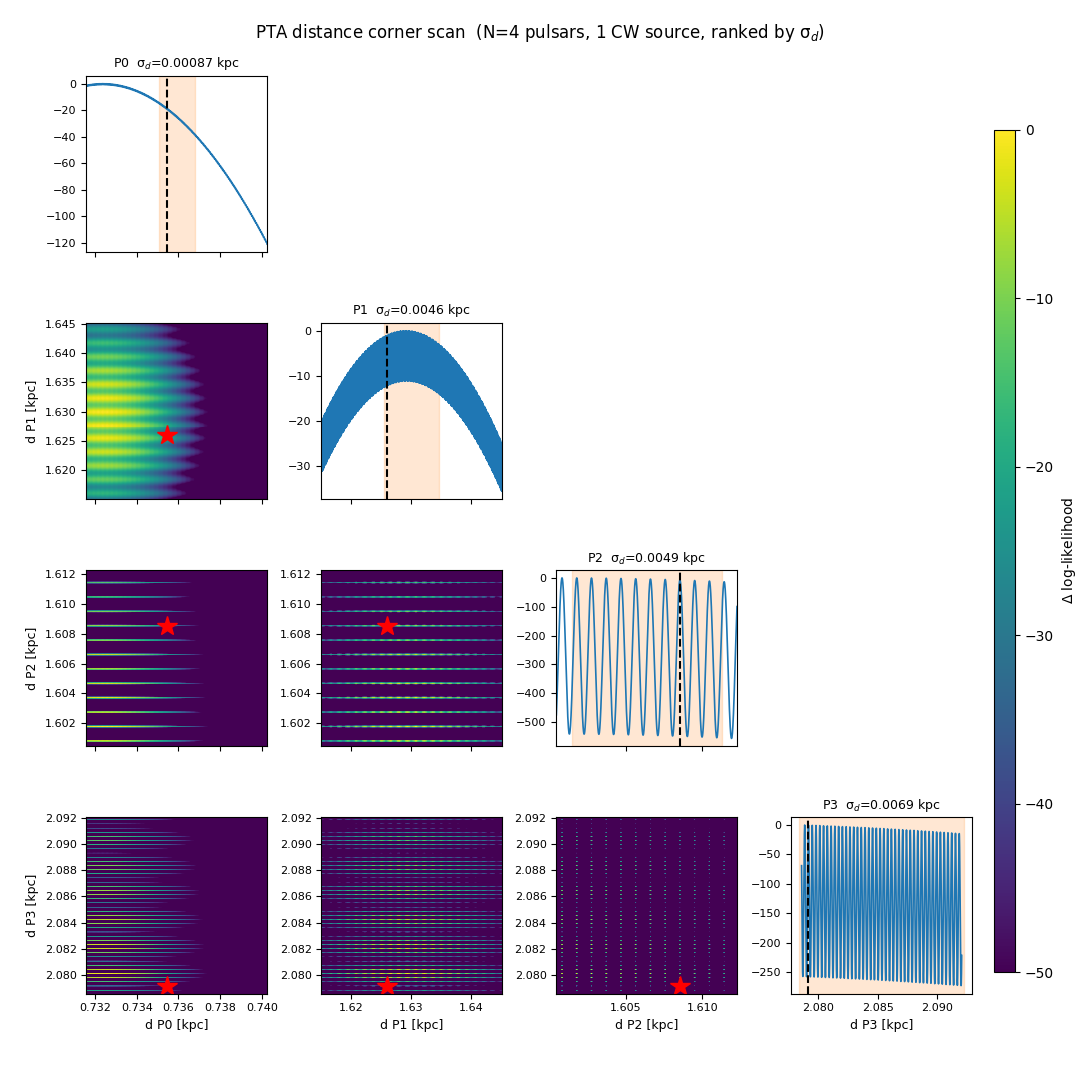

In [15]:
fig, axes = plt.subplots(
    N_PULSARS, N_PULSARS,
    figsize=(2.7 * N_PULSARS, 2.7 * N_PULSARS),
    sharex="col",
)
if N_PULSARS == 1:
    axes = np.array([[axes]])

last_mesh = None
for r in range(N_PULSARS):
    for c in range(N_PULSARS):
        ax = axes[r, c]
        if c > r:
            ax.set_visible(False)
            continue
        i_o = order_int[r]   # row pulsar (larger sigma_d in the lower triangle)
        j_o = order_int[c]   # column pulsar (smaller sigma_d in the lower triangle)
        if r == c:
            r1 = results_1d[i_o]
            plot_1d_delta_logL(
                ax, r1["dist_kpc"], r1["logL"], true_value=true_d_kpc[i_o],
            )
            ax.set_ylabel("")  # override helper's default ylabel for tidiness
            d, s = wls[i_o]["d_best"], wls[i_o]["sigma_d"]
            ax.axvspan(d - s, d + s, alpha=0.18, color="C1")
            ax.set_title(f"P{i_o}  σ$_d$={s:.2g} kpc", fontsize=9)
        else:
            key = (j_o, i_o)
            if key not in results_2d:
                ax.text(
                    0.5, 0.5, "(skipped)",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=9, color="0.5",
                )
                ax.set_xticks([]); ax.set_yticks([])
                continue
            entry = results_2d[key]
            mesh = plot_2d_delta_logL(
                ax,
                entry["x_dist_kpc"], entry["y_dist_kpc"], entry["logL_2d"],
                true_xy=(true_d_kpc[j_o], true_d_kpc[i_o]),
            )
            mesh.set_clim(COLORBAR_VMIN, 0.0)
            last_mesh = mesh
        if r == N_PULSARS - 1:
            ax.set_xlabel(f"d P{order_int[c]} [kpc]", fontsize=9)
        if c == 0 and r > 0:
            ax.set_ylabel(f"d P{order_int[r]} [kpc]", fontsize=9)
        ax.tick_params(labelsize=8)

fig.suptitle(
    f"PTA distance corner scan  (N={N_PULSARS} pulsars, {M_CW_SOURCES} CW "
    f"source{'s' if M_CW_SOURCES > 1 else ''}, ranked by σ$_d$)",
    fontsize=12,
)
fig.subplots_adjust(left=0.08, right=0.9, top=0.93, bottom=0.08, hspace=0.4, wspace=0.3)
if last_mesh is not None:
    cax = fig.add_axes([0.92, 0.10, 0.02, 0.78])
    fig.colorbar(last_mesh, cax=cax, label=r"$\Delta$ log-likelihood")
plt.show()

## Reading the figure

- **Diagonal panels** show the 1D $\Delta$ log-likelihood for each pulsar's distance with all other pulsars at truth. The dashed black line is the injected truth; the orange band is the WLS $\pm 1\sigma$ on the fit-derived distance.
- **Lower-triangle panels** show the 2D $\Delta$ log-likelihood for each unique pair, with the column pulsar's distance on the x-axis and the row pulsar's distance on the y-axis. The red star marks the injected (truth, truth).
- The matrix is sorted from most-constraining pulsar (top-left) to least-constraining (bottom-right), so the highest-information pair sits at row 1, column 0.
- Multiple peaks along an axis are the pulsar-term phase-matching degeneracies $\phi_p = \phi_e - 2\pi f_{gw}\, d\,(1+\cos\mu)/c$; their period along that axis is $\Delta d = c / [f_{gw}(1+\cos\mu)]$, set by that pulsar's opening angle to the CW source.
- All 2D panels share the colorbar floor `COLORBAR_VMIN`; raise it (closer to 0) if individual panels look washed out.
- Each panel is centered on the **WLS best-fit**, not the injected truth. In period mode, the truth marker may sit outside the panel when the WLS error exceeds a few pulsar-term periods; bump N_PERIODS or switch to WINDOW_MODE="sigma" to bring it back into view.